# 2장 4강: 이벤트 로그 기반 AARRR 퍼널 집계 및 시각화 — 실습문제

## 실습 목표

- 계정·구독·기능 사용 데이터를 연결하여 퍼널 단계 도달 기록을 만들 수 있다.
- `groupby()`와 `nunique()`로 단계별 고유 계정 수를 집계할 수 있다.
- 전 단계 대비 전환율과 최초 단계 대비 전체 전환율을 계산할 수 있다.
- 퍼널을 가로 막대그래프로 시각화하고 이탈 집중 구간을 찾을 수 있다.
- 수치에서 확인한 이탈 구간을 바탕으로 개선 가설과 검증 방법을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_accounts.csv`
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 구독형 B2B SaaS입니다. 이번 실습에서는 다음 네 단계를 누적 퍼널로 정의합니다.

| 단계 | 도달 조건 |
|---|---|
| Acquisition | 관찰 종료일보다 30일 이상 앞서 가입한 계정 |
| Activation | 가입 후 30일 이내 첫 구독을 시작한 계정 |
| Retention | Activation 계정 중 첫 구독 시작 30일 후에도 유효한 기능 사용 기록이 있는 계정 |
| Revenue | Retention 계정 중 첫 구독이 체험판이 아니고 `mrr_amount > 0`인 계정 |

> Ravenstack 데이터에는 다른 사용자를 추천한 행동을 뜻하는 Referral 이벤트가 없습니다. `referral_source`는 **현재 계정이 유입된 경로**이므로 Referral 행동으로 잘못 사용하지 않고, 이번 실습에서는 측정 가능한 Acquisition~Revenue 4단계만 분석합니다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 세 CSV 파일을 각각 `accounts`, `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치를 확인하세요.
5. 날짜 컬럼을 날짜형으로 변환하세요.
6. 계정별 가장 이른 구독을 `first_subscription`으로 만드세요.
7. 기능 사용 기록에 첫 구독 정보를 결합하고, 구독 시작 전 또는 종료 후 기록을 제외한 `valid_usage`를 만드세요.
8. 기능 사용 데이터의 마지막 날짜에서 30일을 뺀 날짜를 `observation_cutoff`으로 정하세요.

> 가입 직후 30일이 지나지 않은 계정은 Retention 도달 기회가 부족하므로 분석 대상에서 제외합니다.

In [1]:
# 실습 준비 코드를 작성하세요.

import pandas as pd


# 1~2. CSV 불러오기
accounts = pd.read_csv(
    r'C:\Machine_Learning_worksheet\Product_Analysis\데이터\1,2,4장\ravenstack_accounts.csv'
)

subscriptions = pd.read_csv(
    r'C:\Machine_Learning_worksheet\Product_Analysis\데이터\1,2,4장\ravenstack_subscriptions.csv'
)

feature_usage = pd.read_csv(
    r'C:\Machine_Learning_worksheet\Product_Analysis\데이터\1,2,4장\ravenstack_feature_usage.csv'
)


# 3. 행/열 개수 + 상위 5개
print("=== accounts ===")
print(accounts.shape)
display(accounts.head())

print("=== subscriptions ===")
print(subscriptions.shape)
display(subscriptions.head())

print("=== feature_usage ===")
print(feature_usage.shape)
display(feature_usage.head())


# 4. 자료형 + 결측치
for name, df in [
    ('accounts', accounts),
    ('subscriptions', subscriptions),
    ('feature_usage', feature_usage)
]:
    print(f"\n=== {name} ===")
    print(pd.DataFrame({
        'dtype': df.dtypes,
        'missing': df.isna().sum()
    }))


# 5. 날짜형 변환
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])

subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date'] = pd.to_datetime(subscriptions['end_date'])

feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])


# 6. 계정별 가장 이른 구독
first_subscription = (
    subscriptions
    .sort_values('start_date')
    .drop_duplicates('account_id', keep='first')
)

display(first_subscription.head())


# 7. 기능 사용 + 구독 정보 결합
valid_usage = feature_usage.merge(
    subscriptions[
        ['subscription_id', 'account_id', 'start_date', 'end_date']
    ],
    on='subscription_id',
    how='inner'
)

# 구독 시작 전 / 종료 후 기록 제외
valid_usage = valid_usage[
    (valid_usage['usage_date'] >= valid_usage['start_date']) &
    (
        valid_usage['end_date'].isna() |
        (valid_usage['usage_date'] <= valid_usage['end_date'])
    )
].copy()

print("유효 기능 사용 기록:", len(valid_usage))


# 8. 관찰 기준일
observation_cutoff = (
    feature_usage['usage_date'].max()
    - pd.Timedelta(days=30)
)

print("Observation cutoff:", observation_cutoff)

=== accounts ===
(500, 10)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


=== subscriptions ===
(5000, 14)


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaN,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaN,Enterprise,27,5373,64476,False,False,False,False,monthly,True


=== feature_usage ===
(25000, 8)


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False
2,U-096807,S-f29e7f,2023-12-07,feature_3,9,1458,0,False
3,U-6b1580,S-be655e,2024-07-28,feature_40,5,2085,0,False
4,U-720a29,S-f9b1d0,2024-12-02,feature_12,12,900,0,False



=== accounts ===
                 dtype  missing
account_id         str        0
account_name       str        0
industry           str        0
country            str        0
signup_date        str        0
referral_source    str        0
plan_tier          str        0
seats            int64        0
is_trial          bool        0
churn_flag        bool        0

=== subscriptions ===
                   dtype  missing
subscription_id      str        0
account_id           str        0
start_date           str        0
end_date             str     4514
plan_tier            str        0
seats              int64        0
mrr_amount         int64        0
arr_amount         int64        0
is_trial            bool        0
upgrade_flag        bool        0
downgrade_flag      bool        0
churn_flag          bool        0
billing_frequency    str        0
auto_renew_flag     bool        0

=== feature_usage ===
                     dtype  missing
usage_id               str        0
su

,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
4222,S-92f228,A-779e4e,2023-01-09,NaT,Basic,9,171,2052,False,False,False,False,annual,True
2920,S-50aaaa,A-af0cd2,2023-01-12,NaT,Pro,19,931,11172,False,False,False,False,monthly,True
3940,S-6676fa,A-7df7a7,2023-02-05,NaT,Pro,7,343,4116,False,False,True,False,monthly,True
3687,S-fa9b43,A-10b8f2,2023-02-05,NaT,Basic,47,0,0,True,False,False,False,annual,False
450,S-47ce2d,A-d792a6,2023-02-06,NaT,Pro,37,1813,21756,False,False,False,False,monthly,True


유효 기능 사용 기록: 5568
Observation cutoff: 2024-12-01 00:00:00


---

## 필수 1. AARR 단계별 고유 계정 수와 전환율 계산하기

### 문제 1-1. 가입한 계정은 활성화·유지·유료 단계까지 얼마나 도달하는가?

#### 문제 해결 방향

각 단계의 조건을 만족하는 계정 ID를 만들고, 앞 단계에 도달한 계정만 다음 단계에 포함되도록 누적 조건을 적용하세요. 그다음 긴 형태의 `funnel_log`를 만들어 강의에서 배운 `groupby()`와 `nunique()`로 집계합니다.

#### 요구사항

1. `signup_date <= observation_cutoff`인 계정을 `funnel_base`로 만드세요.
2. Acquisition, Activation, Retention, Revenue 도달 여부를 불리언 컬럼으로 만드세요.
3. 단계별 도달 계정만 모아 `account_id`, `stage`로 구성된 `funnel_log`를 만드세요.
4. `groupby("stage")["account_id"].nunique()`로 고유 계정 수를 집계하세요.
5. `reindex()`를 사용해 `Acquisition → Activation → Retention → Revenue` 순서로 정렬하세요.
6. `calc_conversion_rates()` 함수를 작성하여 전 단계 대비 전환율과 전체 대비 전환율을 계산하세요.
7. 단계별 고유 계정 수와 두 전환율을 하나의 `funnel_summary`로 출력하세요.

#### 해석 질문

**Q1.** 이벤트 발생 횟수 대신 고유 계정 수를 사용하는 이유는 무엇인가요?  
한 계정이 같은 기능을 여러번 사용해도 고객은 한계정(중복 X)

**Q2.** 첫 단계의 전 단계 대비 전환율을 100%로 설정하는 이유는 무엇인가요?  
Acquisition 앞에는 비교할 단계가 없음, 이 단계가 퍼널 기준의 모집단임

**Q3.** Retention 단계에 이전 단계 조건을 함께 적용해야 하는 이유는 무엇인가요?  
Activation을 거치지 않은 계정이 Retention에 포함되면 서로 다른 모집단을 사용하여 전체적인 숫자가 맞지 않을 수 있다.

**Q4.** 전 단계 대비 전환율과 전체 대비 전환율은 무엇이 다른가요?

전 단계 대비 전환율은 바로 이전 단계의 고객 중 현재 단걔에 도달한 비율이고, 전체 대비 전환율은 최초 Acquisition 고객 중 현재 단걔까지 도달한 비율이다.


#### 제출 결과

- `funnel_base`와 `funnel_log`
- `calc_conversion_rates()` 함수
- `funnel_summary`
- Q1~Q4 답변

In [2]:
# 필수 1 코드를 작성하세요.

# 1. 분석 대상 계정
funnel_base = accounts[
    accounts['signup_date'] <= observation_cutoff
].copy()


# 2. 단계별 도달 여부

# Acquisition
funnel_base['Acquisition'] = True


# Activation: 기능 사용 기록이 한 번이라도 있는 계정
activated_ids = set(valid_usage['account_id'])

funnel_base['Activation'] = (
    funnel_base['account_id'].isin(activated_ids)
)


# Retention: 가입 30일 이후에도 기능을 사용한 계정
usage_retention = valid_usage.merge(
    accounts[['account_id', 'signup_date']],
    on='account_id',
    how='left'
)

retained_ids = set(
    usage_retention.loc[
        usage_retention['usage_date']
        >= usage_retention['signup_date'] + pd.Timedelta(days=30),
        'account_id'
    ]
)

funnel_base['Retention'] = (
    funnel_base['account_id'].isin(retained_ids)
)


# Revenue: 유료 구독 경험이 있는 계정
paid_ids = set(
    subscriptions.loc[
        subscriptions['mrr_amount'] > 0,
        'account_id'
    ]
)

funnel_base['Revenue'] = (
    funnel_base['account_id'].isin(paid_ids)
)


# 3. funnel_log 만들기
stages = ['Acquisition', 'Activation', 'Retention', 'Revenue']

funnel_log = funnel_base.melt(
    id_vars='account_id',
    value_vars=stages,
    var_name='stage',
    value_name='reached'
)

funnel_log = funnel_log[
    funnel_log['reached']
][['account_id', 'stage']]


# 4~5. 단계별 고유 계정 수
funnel_summary = (
    funnel_log
    .groupby('stage')['account_id']
    .nunique()
    .reindex(stages)
    .reset_index(name='accounts')
)


# 6. 전환율 계산 함수
def calc_conversion_rates(df):
    df = df.copy()

    # 전 단계 대비
    df['step_conversion'] = (
        df['accounts'] / df['accounts'].shift(1)
    )

    # 전체 대비
    df['overall_conversion'] = (
        df['accounts'] / df['accounts'].iloc[0]
    )

    return df


# 7. 최종 결과
funnel_summary = calc_conversion_rates(funnel_summary)

funnel_summary['step_conversion'] = (
    funnel_summary['step_conversion'] * 100
).round(2)

funnel_summary['overall_conversion'] = (
    funnel_summary['overall_conversion'] * 100
).round(2)

display(funnel_summary)

,stage,accounts,step_conversion,overall_conversion
0,Acquisition,483,NaN,100.00
1,Activation,466,96.48,96.48
2,Retention,456,97.85,94.41
3,Revenue,483,105.92,100.00


### 필수 1 답변 작성란

- **Q1.**
Acquisition : 유입, 483개, 전체 500개 중 2024년 12월 1일까지 가입한 계정
- **Q2.**
Activation: 활성화, 위 483건 중 가입일로부터 30일 이내에 첫 활동 을 시작한 계정

- **Q3.**

Retention: 유지, 207개, Activation 에 포함, 첫 구독 시작일 부터 30일 지난 시점에서도 유효한 기능 사용 기록이 있는 계정

- **Q4.**
Revenue: 수익, 177개 , Retention에 포함 되면서 체험판이 아니라 실제 구독료를 낸 계정


---

## 필수 2. 퍼널 시각화와 이탈 구간 개선 가설 만들기

### 문제 2-1. 가장 먼저 개선해야 할 구간은 어디인가?

#### 요구사항

1. 필수 1의 `funnel_summary`를 사용하세요.
2. `barh()`로 단계별 고유 계정 수를 가로 막대그래프로 표시하세요.
3. 막대 옆에 `계정 수 (전 단계 대비 전환율)`을 표시하세요.
4. 첫 단계를 제외하고 전 단계 대비 전환율이 가장 낮은 단계를 찾으세요.
5. 해당 단계와 바로 이전 단계를 이용해 전환율이 가장 낮은 구간을 출력하세요.
6. 이탈 원인 가설 2개와 각 가설의 검증 방법을 제안하세요.

#### 해석 질문

**Q1.** 전 단계 대비 전환율이 가장 낮은 단계와 이탈 구간은 어디인가요?  

Retention 단계가 64.5% 로 가장 낮음, 이탈 구간은 Activation -> Retention

**Q2.** 퍼널 결과만으로 이탈의 원인을 확정할 수 있나요?  
없다. 퍼널은 계정이 많이 줄어든 구간을 보여준다.
기능, 오류, 지원 등에 대한 원인은 추가적인 데이터 분석을 통해 확인할 수 있따.

**Q3.** 해당 구간을 개선하기 위해 어떤 데이터를 추가로 확인할 수 있나요?
오류 수, 오류 종류, 고객 지원, 프로모션 등을 확인할 수 있다.



#### 제출 결과

- 전환율을 표시한 퍼널 그래프
- 가장 낮은 전환 단계와 이탈 구간
- 개선 가설 2개와 검증 방법
- Q1~Q3 답변

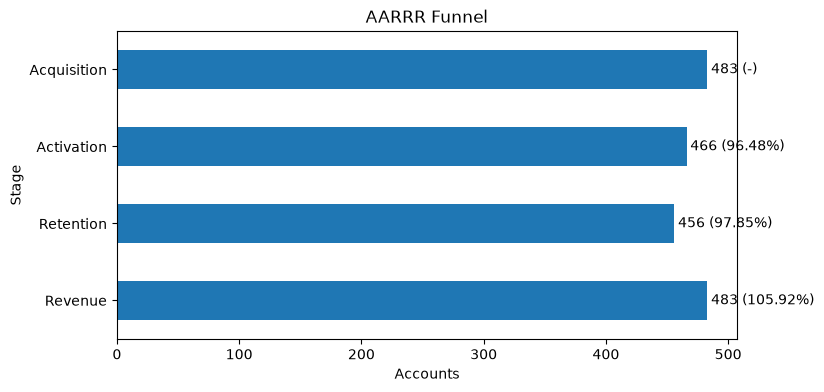

가장 낮은 단계: Activation
전환율: 96.48 %


In [3]:
# 필수 2 코드를 작성하세요.
import matplotlib.pyplot as plt
import pandas as pd


# 1~3. 가로 막대그래프
ax = funnel_summary.plot.barh(
    x='stage',
    y='accounts',
    legend=False,
    figsize=(8, 4)
)

# 막대 옆에 계정 수 + 전 단계 대비 전환율 표시
for i, row in funnel_summary.iterrows():

    rate = (
        "-"
        if pd.isna(row['step_conversion'])
        else f"{row['step_conversion']:.2f}%"
    )

    ax.text(
        row['accounts'] + 3,
        i,
        f"{row['accounts']} ({rate})",
        va='center'
    )

plt.xlabel('Accounts')
plt.ylabel('Stage')
plt.title('AARRR Funnel')
plt.gca().invert_yaxis()
plt.show()


# 4. 전환율이 가장 낮은 단계
lowest = (
    funnel_summary.iloc[1:]
    .loc[funnel_summary.iloc[1:]['step_conversion'].idxmin()]
)

print("가장 낮은 단계:", lowest['stage'])
print("전환율:", lowest['step_conversion'], "%")

### 필수 2 답변 작성란

- **Q1.**
- **Q2.**
- **Q3.**

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 첫 구독 요금제별 퍼널 비교와 개선 가설 제안하기

#### 문제 설명

첫 구독의 plan_tier별로 Acquisition → Activation → Retention → Revenue 단계의 계정 수와 전환율을 비교하세요. 이탈이 집중된 구간을 찾고, 개선 가설과 검증 방법을 제안하세요.

> 필수 문제의 단계 정의와 집계·전환율 계산·시각화 절차를 그대로 활용합니다. Referral은 관련 행동 기록이 없어 분석에서 제외합니다.

#### 요구사항

1. 원시 계정·구독·기능 사용 데이터를 연결하여 funnel_base와 단계 도달 여부를 만드는 코드를 제출물에 포함하세요. 필수 문제에서 작성한 코드를 재사용해도 됩니다.
2. 첫 구독의 plan_tier별로 Acquisition, Activation, Retention, Revenue의 고유 계정 수를 집계하세요. 각 단계에는 이전 단계에 도달한 계정만 포함하세요.
3. 요금제별로 다음 값을 계산하여 plan_funnel을 만드세요.
- 구간 전환율 = 현재 단계 계정 수 ÷ 이전 단계 계정 수 × 100
- 구간 이탈률 = 100 − 구간 전환율
- 구간 이탈 계정 수 = 이전 단계 계정 수 − 현재 단계 계정 수
- 첫 단계는 비교할 이전 단계가 없으므로 구간 지표를 빈 값으로 두세요. 이전 단계 계정 수가 0이면 전환율·이탈률을 계산 불가로 표시하세요.
4. 요금제별로 단계별 고유 계정 수를 가로 막대그래프로 시각화하고, 각 단계의 구간 전환율을 함께 표시하세요.
5. 첫 단계를 제외하고 전환율이 가장 낮은 요금제·구간 조합을 찾으세요. 해당 구간의 전환율·이탈률·이탈 계정 수를 근거로 이탈 집중 구간을 설명하세요.
6. 요금제별 최종 Revenue 도달률을 계산하여 plan_summary로 출력하세요. 가장 높은 요금제와 낮은 요금제의 차이를 %p로 계산하세요.
- 최종 Revenue 도달률 = Revenue 계정 수 ÷ Acquisition 계정 수 × 100
7. 우선 점검할 구간에 대해 “어떤 원인 때문에 이탈하며, 어떤 변경을 하면 전환율이 개선될 것이다”라는 개선 가설을 한 가지 작성하세요.
8. 가설을 확인하기 위한 추가 데이터 2가지와 검증 방법을 설명하세요. 어떤 대상을 비교하고 어떤 지표로 개선 여부를 판단할지 포함하세요. 실제 실험이나 통계 검정은 수행하지 않아도 됩니다.

#### 해석 질문

Q1. 전환율이 가장 낮은 요금제와 구간은 무엇이며, 전환율·이탈률·이탈 계정 수는 얼마인가요?

Q2. 최종 Revenue 도달률이 가장 높은 요금제와 낮은 요금제는 무엇이며, 차이는 몇 %p인가요?

Q3. 우선 점검할 구간에 대한 개선 가설은 무엇이며, 어떤 데이터와 방법으로 검증할 수 있나요?

Q4. 요금제별 차이만으로 요금제가 이탈의 원인이라고 결론 내릴 수 있나요?

#### 제출 결과

- 원시 데이터 연결 및 단계 도달 여부 구성 코드
- plan_funnel: 단계별 계정 수·전환율·이탈률·이탈 계정 수
- 요금제별 퍼널 그래프
- 이탈 집중 구간과 수치 근거
- plan_summary: 최종 Revenue 도달률과 최고·최저 차이
- 개선 가설·추가 확인 데이터 2가지·검증 방법
- Q1~Q4 답변

In [7]:
# ============================================================
# 5. accounts + 첫 구독 정보 연결 → funnel_base
# ============================================================

first_subscription_merge = first_subscription[
    [
        'account_id',
        'subscription_id',
        'plan_tier',
        'start_date',
        'end_date',
        'mrr_amount',
        'churn_flag',
        'has_usage'
    ]
].copy()

# 충돌 방지를 위해 첫 구독 변수 이름 변경
first_subscription_merge = first_subscription_merge.rename(
    columns={
        'plan_tier': 'first_plan_tier',
        'churn_flag': 'subscription_churn_flag'
    }
)

funnel_base = accounts.merge(
    first_subscription_merge,
    on='account_id',
    how='inner'
)


# ============================================================
# 6. 퍼널 단계 도달 여부
# ============================================================

funnel_base['Acquisition'] = True

funnel_base['Activation'] = (
    funnel_base['Acquisition']
    & funnel_base['has_usage']
)

funnel_base['Retention'] = (
    funnel_base['Activation']
    & (funnel_base['subscription_churn_flag'] == False)
)

funnel_base['Revenue'] = (
    funnel_base['Retention']
    & (funnel_base['mrr_amount'] > 0)
)


print("=== funnel_base ===")

display(
    funnel_base[
        [
            'account_id',
            'subscription_id',
            'first_plan_tier',
            'Acquisition',
            'Activation',
            'Retention',
            'Revenue'
        ]
    ].head()
)


# ============================================================
# 7. 첫 구독 요금제별 단계 고유 계정 수
# ============================================================

stages = [
    'Acquisition',
    'Activation',
    'Retention',
    'Revenue'
]

rows = []

for plan in sorted(
    funnel_base['first_plan_tier'].dropna().unique()
):

    temp = funnel_base[
        funnel_base['first_plan_tier'] == plan
    ]

    previous_count = None

    for stage in stages:

        current_count = temp.loc[
            temp[stage],
            'account_id'
        ].nunique()

        if previous_count is None:
            conversion_rate = np.nan
            dropoff_rate = np.nan
            dropoff_count = np.nan

        elif previous_count == 0:
            conversion_rate = np.nan
            dropoff_rate = np.nan
            dropoff_count = 0

        else:
            conversion_rate = (
                current_count / previous_count * 100
            )

            dropoff_rate = (
                100 - conversion_rate
            )

            dropoff_count = (
                previous_count - current_count
            )

        rows.append({
            'plan_tier': plan,
            'stage': stage,
            'account_count': current_count,
            'conversion_rate': conversion_rate,
            'dropoff_rate': dropoff_rate,
            'dropoff_count': dropoff_count
        })

        previous_count = current_count


plan_funnel = pd.DataFrame(rows)

display(
    plan_funnel.style.format({
        'conversion_rate': '{:.2f}%',
        'dropoff_rate': '{:.2f}%',
        'dropoff_count': '{:.0f}'
    })
)

=== funnel_base ===


,account_id,subscription_id,first_plan_tier,Acquisition,Activation,Retention,Revenue
0,A-2e4581,S-7ce677,Pro,True,True,True,True
1,A-43a9e3,S-0d2fb8,Basic,True,True,True,True
2,A-0a282f,S-a346d6,Enterprise,True,True,False,False
3,A-1f0ac7,S-da7f1f,Pro,True,True,True,True
4,A-ce550d,S-e1de58,Enterprise,True,True,True,True


,plan_tier,stage,account_count,conversion_rate,dropoff_rate,dropoff_count
0,Basic,Acquisition,164,nan%,nan%,nan
1,Basic,Activation,163,99.39%,0.61%,1
2,Basic,Retention,149,91.41%,8.59%,14
3,Basic,Revenue,121,81.21%,18.79%,28
4,Enterprise,Acquisition,171,nan%,nan%,nan
5,Enterprise,Activation,170,99.42%,0.58%,1
6,Enterprise,Retention,155,91.18%,8.82%,15
7,Enterprise,Revenue,128,82.58%,17.42%,27
8,Pro,Acquisition,165,nan%,nan%,nan
9,Pro,Activation,164,99.39%,0.61%,1


### 과제 1 답변 작성란

- **Q1.**

가장 낮은 조합은 Basic 요금제 retentiion-> revenue 구간
전환율 : 84.21%
이탈율: 18.79%
이탈 계정수 : 28개
revenue로 이어지지 않은 비율이 높음


- **Q2.**

가장 높은 요금제는 pro 75.15%, 가장 낮은 요금제는 basic 73.8% 차이는 1.37%

- **Q3.**
Basic 이용자는 서비는 이용하더라도 가성비와 같은 문제로 결제 조건때문에 revenue로 전환이 안되었을수도 잇음



- **Q4.**
아니요 요금제가 원인이라는 명확한 근거는 없습니다.

고객의 규모, 고객 사용층, 사용 기간 같은것도 고려를 해야한다. 왜냐하면 앞서 2번에서 차이가 1.37%로 전환율에 크게 차이가 없다는걸 보았기 때문에.


---

## 실습 마무리

1. 이번 분석에서는 각 AARR 단계를 어떤 조건으로 정의했나요?

Acquisition(유입), Activation, Retention, Revenue

2. 단계별 고유 계정 수는 어떤 코드로 집계했나요?
Groupby('stage')['account_id'].nunique()


3. 전 단계 대비 전환율과 전체 대비 전환율은 각각 무엇을 보여주나요?
전자는 바로 이전 단계에서 유지한 비율
후자는 Acquisition 계정 중 현재 단계까지 남은 비율

4. 어느 구간에서 이탈이 가장 집중되었나요?
64.5%, Activation -> Retention 구간

5. 퍼널 수치와 이탈 원인을 왜 구분해야 하나요?
퍼널은 이탈 단계를 보여주지만 이탈의 직접적인 원인은 추가 데이터로 검증이 필요하다.

6. Referral 단계를 이번 분석에서 제외한 이유는 무엇인가요?
다른 사용자를 추천한 행동이나 추천 성공을 나타내는 이벤트가 없었다.

